In [5]:
from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Combining Multiple Decision Trees via Random Forests

Ensemble methods like random forests are highly popular in machine learning because of their excellent classification performance, scalability, ease of use, and robustness against overfitting.

A random forest can be considered an ensemble of decision trees. The core idea is to average multiple (often deep) decision trees that individually suffer from high variance to build a more robust model that generalizes better to unseen data.

### The Random Forest Algorithm
The algorithm can be summarized in four main steps:

1. **Bootstrap Sampling:** Draw a random bootstrap sample of size $n$ (randomly choose $n$ examples from the training dataset *with replacement*).
2. **Grow a Decision Tree:** Grow a tree from the bootstrap sample. At each node:
   * Randomly select $d$ features *without replacement*.
   * Split the node using the feature that provides the best split according to the objective function (e.g., maximizing information gain or using Gini impurity).
3. **Repeat:** Repeat steps 1 and 2 $k$ times to build $k$ trees.
4. **Aggregate:** Aggregate the predictions of each tree to assign the final class label by **majority vote**.

### Hyperparameters and the Bias-Variance Tradeoff
A major advantage of random forests is that they require minimal hyperparameter tuning. Because averaging the predictions protects against noise, you typically don't need to prune the individual trees.

* **Number of Trees ($k$):** The primary parameter you need to care about. Generally, a larger number of trees improves performance at the expense of increased computational cost.
* **Bootstrap Sample Size ($n$):** Controls the bias-variance tradeoff.
  * *Decreasing* $n$ shrinks the sample size, increasing the randomness and diversity among trees. This helps reduce overfitting but might lower overall performance.
  * *Increasing* $n$ makes the bootstrap samples (and thus the trees) more similar to each other, which fits the training data more closely but increases the risk of overfitting.
  * *Default:* In scikit-learn, the default size of the bootstrap sample is equal to the total number of training examples.
* **Number of Features ($d$):** At each split, you want to choose a value smaller than the total number of features ($m$). A standard default used in scikit-learn is $d = \sqrt{m}$.

### Implementation in Scikit-Learn

`scikit-learn` provides a highly optimized implementation that takes care of constructing the individual trees for you.

In [6]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

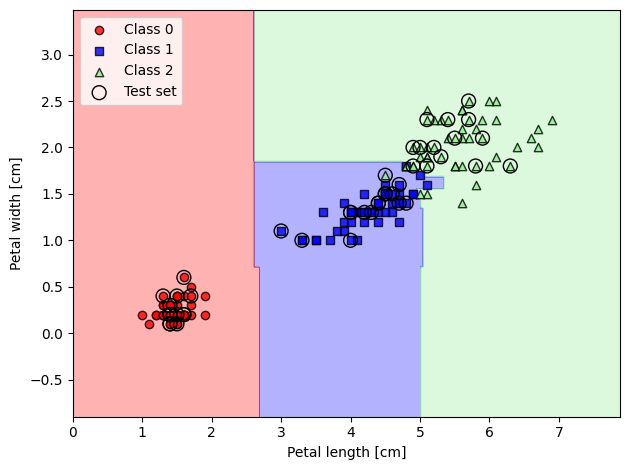

In [7]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier
# n_estimators: Number of trees (k)
# n_jobs: Number of CPU cores used to parallelize training
forest = RandomForestClassifier(n_estimators=25,
                                random_state=1,
                                n_jobs=2)

# Train the model
forest.fit(X_train, y_train)

# Plotting decision regions (assuming a custom plot_decision_regions function is defined)
plot_decision_regions(X_combined, y_combined,
                      classifier=forest,
                      test_idx=range(105, 150))

plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()